# Random Graph Analysis using PageRank, Dimensionality Reduction, and GMM Clustering

### Authors
Sudarshan Damodharan, Adithya Bhaskara, Ali Haroon

## Project Motivation

Many real-world systems can be modeled as networks, including social contact networks, information-sharing systems, and transportation systems. The structure of a network strongly affects how influence, information, or disease spreads through it.

In this project, we compare three random graph models:

- **Erdős–Rényi (ER)**: random independent edge formation
- **Watts–Strogatz (WS)**: small-world structure with local clustering
- **Barabási–Albert (BA)**: preferential attachment leading to hubs

Our goal is to study how network structure affects:

1. the distribution of node influence, measured using **PageRank**
2. the emergence of distinct **node roles**, identified using graph-derived features and **Gaussian Mixture Model (GMM)** clustering

This question is motivated by applications such as disease spread and antidote distribution, where highly influential nodes may represent especially important intervention targets.

## Research Questions

We focus on the following questions:

1. How does graph structure affect the concentration of PageRank scores?
2. How do graph models differ in terms of graph-derived node features such as degree, clustering coefficient, betweenness, and closeness?
3. Can dimensionality reduction and clustering reveal distinct structural node roles such as hubs, bridges, and peripheral nodes?
4. Are these patterns consistent across repeated graph realizations?

## Methods Overview

For each graph model, we:

- generate multiple synthetic graphs
- compute PageRank and other graph-derived node features
- reduce feature dimension using **PCA**
- cluster nodes using **Gaussian Mixture Models**
- compare the models using summary statistics, visualizations, and repeated experiments

## Why Synthetic Data is Appropriate

This project uses synthetically generated graph data rather than observational data. This is appropriate because the goal is not to fit a specific real-world dataset, but rather to compare how different **network generation mechanisms** produce different influence patterns and structural roles. Because we control the data-generating process, we can isolate the effect of graph topology on the downstream methods.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 4)

## 1. Graph Generation

We generate graphs from three standard random graph models.

- In **Erdős–Rényi**, each possible edge appears independently with probability \( p \).
- In **Watts–Strogatz**, nodes begin in a ring lattice and some edges are rewired with probability \( \beta \), creating a small-world network.
- In **Barabási–Albert**, new nodes attach preferentially to high-degree nodes, generating hubs.

To make comparisons meaningful, we will use similar graph sizes across models.

In [2]:
def generate_erdos_renyi(n: int, p: float, seed: int | None = None) -> nx.Graph:
    return nx.erdos_renyi_graph(n=n, p=p, seed=seed)

def generate_watts_strogatz(n: int, k: int, beta: float, seed: int | None = None) -> nx.Graph:
    return nx.watts_strogatz_graph(n=n, k=k, p=beta, seed=seed)

def generate_barabasi_albert(n: int, m: int, seed: int | None = None) -> nx.Graph:
    return nx.barabasi_albert_graph(n=n, m=m, seed=seed)

def generate_graph(model: str, n: int, seed: int | None = None, **kwargs) -> nx.Graph:
    model = model.upper()
    if model == "ER":
        return generate_erdos_renyi(n=n, p=kwargs["p"], seed=seed)
    elif model == "WS":
        return generate_watts_strogatz(n=n, k=kwargs["k"], beta=kwargs["beta"], seed=seed)
    elif model == "BA":
        return generate_barabasi_albert(n=n, m=kwargs["m"], seed=seed)
    else:
        raise ValueError(f"Unknown model: {model}")

In [4]:
# Baseline parameters
N = 1000

ER_PARAMS = {"p": 0.03}
WS_PARAMS = {"k": 6, "beta": 0.2}
BA_PARAMS = {"m": 3}

In [5]:
seed = 42

G_er = generate_graph("ER", n=N, seed=seed, **ER_PARAMS)
G_ws = generate_graph("WS", n=N, seed=seed, **WS_PARAMS)
G_ba = generate_graph("BA", n=N, seed=seed, **BA_PARAMS)

print("ER:", G_er.number_of_nodes(), "nodes,", G_er.number_of_edges(), "edges")
print("WS:", G_ws.number_of_nodes(), "nodes,", G_ws.number_of_edges(), "edges")
print("BA:", G_ba.number_of_nodes(), "nodes,", G_ba.number_of_edges(), "edges")

ER: 1000 nodes, 14840 edges
WS: 1000 nodes, 3000 edges
BA: 1000 nodes, 2991 edges


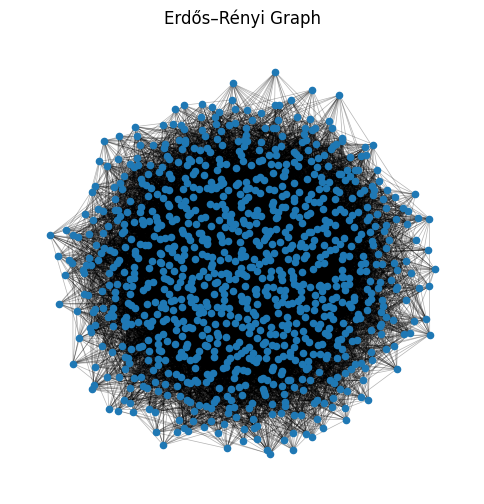

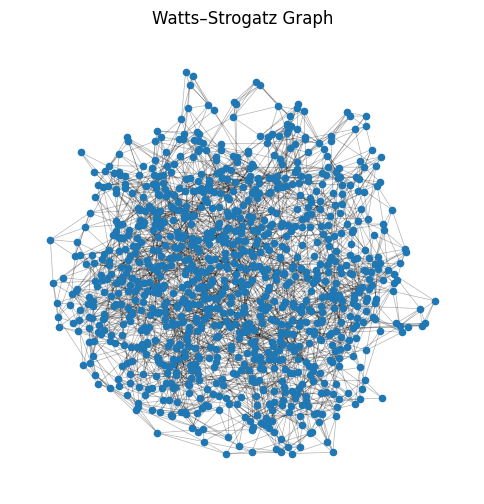

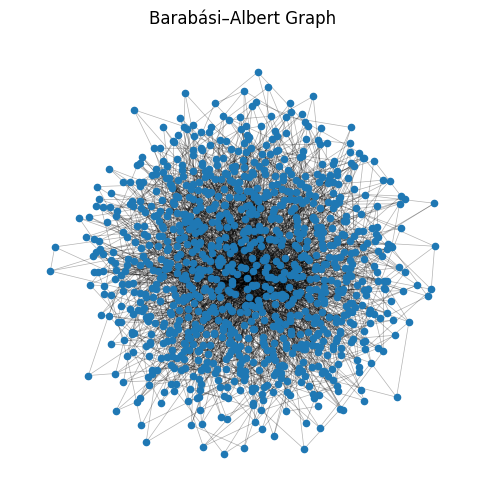

In [6]:
def plot_graph(G: nx.Graph, title: str):
    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw_networkx_nodes(G, pos, node_size=20)
    nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.5)
    plt.title(title)
    plt.axis("off")
    plt.show()

plot_graph(G_er, "Erdős–Rényi Graph")
plot_graph(G_ws, "Watts–Strogatz Graph")
plot_graph(G_ba, "Barabási–Albert Graph")

## 2. PageRank and Feature Engineering

PageRank is a classic graph-based measure of node importance. In our context, it serves as a proxy for node influence under a repeated diffusion or random-walk process.

To go beyond a single centrality measure, we compute several node-level features:

- **degree**
- **PageRank**
- **clustering coefficient**
- **betweenness centrality**
- **closeness centrality**

These features allow us to compare the different graph models and later cluster nodes into structural roles.

In [7]:
def compute_pagerank(G: nx.Graph, alpha: float = 0.85) -> dict:
    return nx.pagerank(G, alpha=alpha)

def extract_node_features(G: nx.Graph, model_name: str) -> pd.DataFrame:
    pagerank = compute_pagerank(G)
    degree_dict = dict(G.degree())
    clustering_dict = nx.clustering(G)
    betweenness_dict = nx.betweenness_centrality(G)
    closeness_dict = nx.closeness_centrality(G)

    df = pd.DataFrame({
        "node": list(G.nodes()),
        "degree": [degree_dict[node] for node in G.nodes()],
        "pagerank": [pagerank[node] for node in G.nodes()],
        "clustering_coef": [clustering_dict[node] for node in G.nodes()],
        "betweenness": [betweenness_dict[node] for node in G.nodes()],
        "closeness": [closeness_dict[node] for node in G.nodes()],
        "model": model_name
    })

    df["log_degree"] = np.log1p(df["degree"])
    df["log_pagerank"] = np.log1p(df["pagerank"])
    return df

In [8]:
df_er = extract_node_features(G_er, "ER")
df_ws = extract_node_features(G_ws, "WS")
df_ba = extract_node_features(G_ba, "BA")

df_er.head()

,node,degree,pagerank,clustering_coef,betweenness,closeness,model,log_degree,log_pagerank
0,0,30,0.0010,0.0368,0.0013,0.4238,ER,3.4340,0.0010
1,1,26,0.0009,0.0308,0.0010,0.4132,ER,3.2958,0.0009
2,2,31,0.0010,0.0194,0.0014,0.4275,ER,3.4657,0.0010
3,3,22,0.0008,0.0173,0.0007,0.4056,ER,3.1355,0.0008
4,4,30,0.0010,0.0345,0.0013,0.4271,ER,3.4340,0.0010


In [9]:
feature_cols = [
    "degree",
    "pagerank",
    "clustering_coef",
    "betweenness",
    "closeness",
    "log_degree",
    "log_pagerank"
]

print("ER summary")
display(df_er[feature_cols].describe())

print("WS summary")
display(df_ws[feature_cols].describe())

print("BA summary")
display(df_ba[feature_cols].describe())

ER summary


,degree,pagerank,clustering_coef,betweenness,closeness,log_degree,log_pagerank
count,1000.000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,29.680,0.0010,0.0302,0.0014,0.4220,3.4077,0.0010
std,5.406,0.0002,0.0087,0.0005,0.0131,0.1802,0.0002
min,14.000,0.0006,0.0048,0.0003,0.3786,2.7081,0.0006
25%,26.000,0.0009,0.0242,0.0010,0.4132,3.2958,0.0009
50%,29.000,0.0010,0.0300,0.0013,0.4221,3.4012,0.0010
75%,33.000,0.0011,0.0351,0.0017,0.4310,3.5264,0.0011
max,47.000,0.0015,0.0667,0.0033,0.4585,3.8712,0.0015


WS summary


,degree,pagerank,clustering_coef,betweenness,closeness,log_degree,log_pagerank
count,1000.0000,1000.0000,1000.0000,1.0000e+03,1000.0000,1000.0000,1000.0000
mean,6.0000,0.0010,0.3223,4.1611e-03,0.1945,1.9354,0.0010
std,1.0035,0.0001,0.1458,2.8114e-03,0.0092,0.1463,0.0001
min,3.0000,0.0006,0.0000,8.9414e-05,0.1655,1.3863,0.0006
25%,5.0000,0.0009,0.2000,1.9940e-03,0.1883,1.7918,0.0009
50%,6.0000,0.0010,0.3333,3.6160e-03,0.1946,1.9459,0.0010
75%,7.0000,0.0011,0.4000,5.6844e-03,0.2007,2.0794,0.0011
max,10.0000,0.0015,0.7000,1.7127e-02,0.2216,2.3979,0.0015


BA summary


,degree,pagerank,clustering_coef,betweenness,closeness,log_degree,log_pagerank
count,1000.0000,1000.0000,1000.0000,1.0000e+03,1000.0000,1000.0000,1000.0000
mean,5.9820,0.0010,0.0333,2.4714e-03,0.2911,1.7637,0.0010
std,7.2676,0.0010,0.0888,9.7581e-03,0.0284,0.4929,0.0010
min,3.0000,0.0005,0.0000,2.8822e-05,0.2287,1.3863,0.0005
25%,3.0000,0.0006,0.0000,2.3432e-04,0.2698,1.3863,0.0006
50%,4.0000,0.0007,0.0000,5.2093e-04,0.2868,1.6094,0.0007
75%,6.0000,0.0010,0.0084,1.6023e-03,0.3093,1.9459,0.0010
max,93.0000,0.0133,0.6667,1.5128e-01,0.4368,4.5433,0.0132


The summary statistics already provide a first look at how the graph models differ. In particular, we are interested in whether some models create much more unequal influence distributions than others. Since Barabási–Albert graphs contain hubs by construction, we expect them to exhibit larger variation in degree and PageRank than Erdős–Rényi graphs.

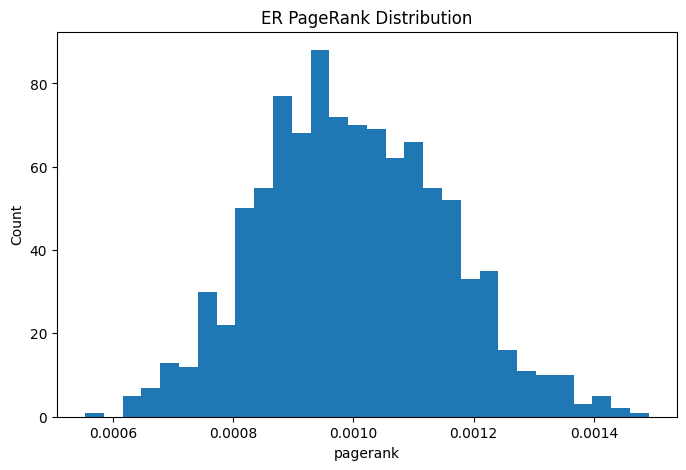

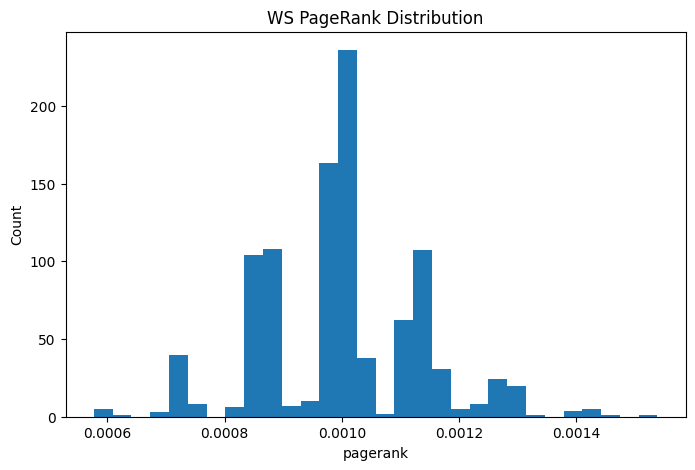

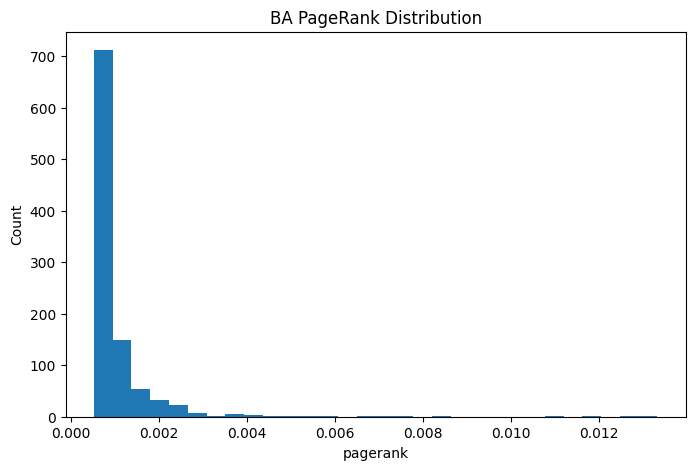

In [10]:
def plot_histogram(df: pd.DataFrame, column: str, title: str, bins: int = 30):
    plt.figure()
    plt.hist(df[column], bins=bins)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

plot_histogram(df_er, "pagerank", "ER PageRank Distribution")
plot_histogram(df_ws, "pagerank", "WS PageRank Distribution")
plot_histogram(df_ba, "pagerank", "BA PageRank Distribution")

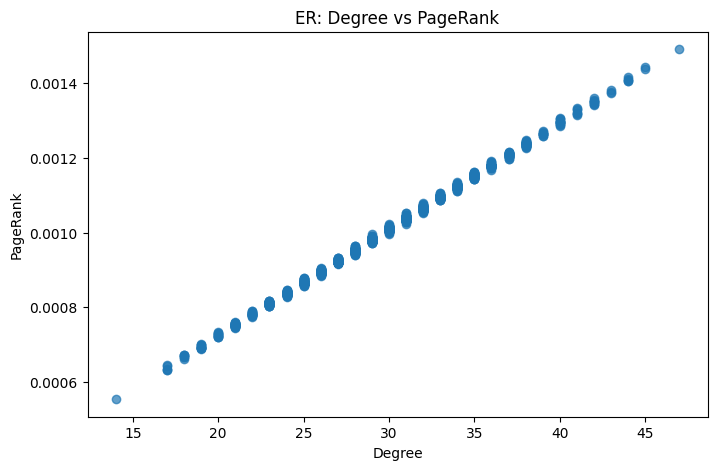

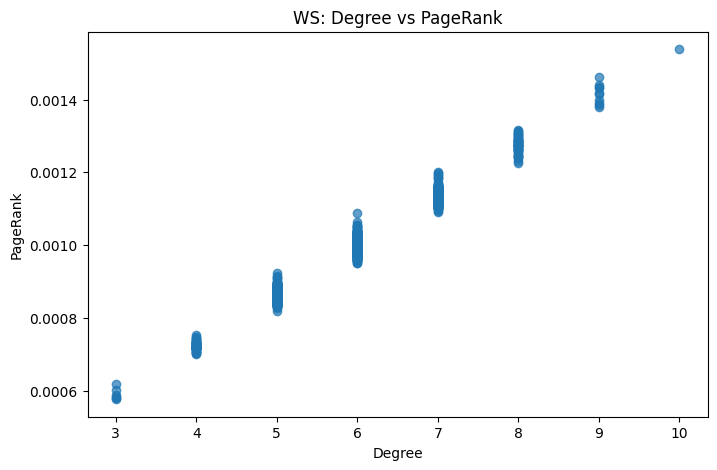

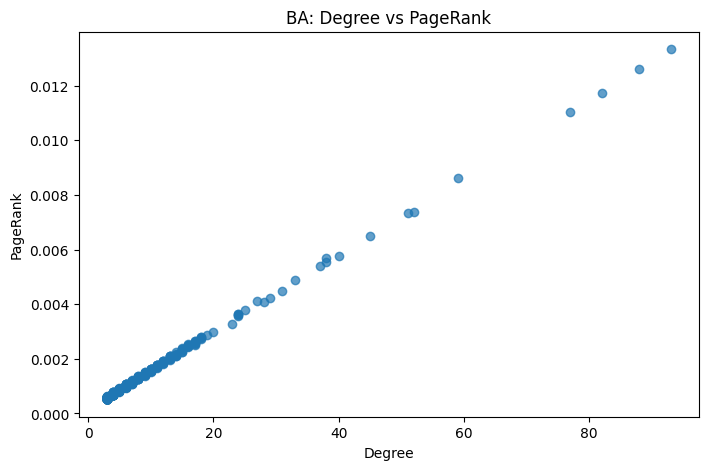

In [11]:
def plot_degree_vs_pagerank(df: pd.DataFrame, title: str):
    plt.figure()
    plt.scatter(df["degree"], df["pagerank"], alpha=0.7)
    plt.xlabel("Degree")
    plt.ylabel("PageRank")
    plt.title(title)
    plt.show()

plot_degree_vs_pagerank(df_er, "ER: Degree vs PageRank")
plot_degree_vs_pagerank(df_ws, "WS: Degree vs PageRank")
plot_degree_vs_pagerank(df_ba, "BA: Degree vs PageRank")

In [12]:
def correlation_table(df: pd.DataFrame) -> pd.DataFrame:
    cols = ["degree", "pagerank", "clustering_coef", "betweenness", "closeness"]
    return df[cols].corr()

print("ER correlations")
display(correlation_table(df_er))

print("WS correlations")
display(correlation_table(df_ws))

print("BA correlations")
display(correlation_table(df_ba))

ER correlations


,degree,pagerank,clustering_coef,betweenness,closeness
degree,1.0000,0.9995,0.0257,0.9873,0.9758
pagerank,0.9995,1.0000,0.0188,0.9898,0.9706
clustering_coef,0.0257,0.0188,1.0000,-0.0234,0.0213
betweenness,0.9873,0.9898,-0.0234,1.0000,0.9480
closeness,0.9758,0.9706,0.0213,0.9480,1.0000


WS correlations


,degree,pagerank,clustering_coef,betweenness,closeness
degree,1.0000,0.9898,-0.2790,0.6847,0.5271
pagerank,0.9898,1.0000,-0.3047,0.6851,0.5093
clustering_coef,-0.2790,-0.3047,1.0000,-0.7261,-0.6866
betweenness,0.6847,0.6851,-0.7261,1.0000,0.8164
closeness,0.5271,0.5093,-0.6866,0.8164,1.0000


BA correlations


,degree,pagerank,clustering_coef,betweenness,closeness
degree,1.0000,0.9995,-0.0639,0.9538,0.6410
pagerank,0.9995,1.0000,-0.0722,0.9491,0.6316
clustering_coef,-0.0639,-0.0722,1.0000,-0.0375,0.2109
betweenness,0.9538,0.9491,-0.0375,1.0000,0.5624
closeness,0.6410,0.6316,0.2109,0.5624,1.0000


## 3. Measuring Influence Concentration

To compare how unequal the PageRank distribution is across graph models, we compute several summary statistics, including the standard deviation and maximum PageRank score. We also compute a **Gini coefficient** as a summary of inequality.

A larger Gini coefficient indicates that influence is concentrated among relatively few nodes.

In [13]:
def gini(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    if np.any(x < 0):
        raise ValueError("Gini coefficient is not defined for negative values.")
    if np.allclose(x.sum(), 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * x) / (n * np.sum(x))) - (n + 1) / n

def influence_summary(df: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "pagerank_mean": df["pagerank"].mean(),
        "pagerank_std": df["pagerank"].std(),
        "pagerank_max": df["pagerank"].max(),
        "pagerank_gini": gini(df["pagerank"].values),
        "degree_mean": df["degree"].mean(),
        "degree_std": df["degree"].std()
    })

summary_one_run = pd.DataFrame({
    "ER": influence_summary(df_er),
    "WS": influence_summary(df_ws),
    "BA": influence_summary(df_ba)
}).T

summary_one_run

,pagerank_mean,pagerank_std,pagerank_max,pagerank_gini,degree_mean,degree_std
ER,0.001,0.0002,0.0015,0.0871,29.680,5.4060
WS,0.001,0.0001,0.0015,0.0756,6.000,1.0035
BA,0.001,0.0010,0.0133,0.3266,5.982,7.2676


From a single run, we can already compare the concentration of influence across graph models. However, a single realization may not be representative. To make the analysis more rigorous, we next repeat the experiment across multiple random seeds.

## 4. Dimensionality Reduction with PCA

Because the node features are correlated and live in a moderately high-dimensional space, we apply **Principal Component Analysis (PCA)** to reduce the features to two dimensions for visualization.

This helps us study whether different node roles separate naturally in feature space.

In [14]:
def run_pca(df: pd.DataFrame, cols: list[str], n_components: int = 2):
    X = df[cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    out = df.copy()
    for i in range(n_components):
        out[f"PC{i+1}"] = X_pca[:, i]

    return out, pca, scaler

In [15]:
df_ba_pca, pca_ba, scaler_ba = run_pca(df_ba, feature_cols, n_components=2)

print("Explained variance ratio (BA):", pca_ba.explained_variance_ratio_)
df_ba_pca.head()

Explained variance ratio (BA): [0.73349077 0.1578773 ]


,node,degree,pagerank,clustering_coef,betweenness,closeness,model,log_degree,log_pagerank,PC1,PC2
0,0,52,0.0074,0.0294,0.0718,0.4145,BA,3.9703,0.0073,14.2157,0.1126
1,1,31,0.0045,0.0237,0.0310,0.3742,BA,3.4657,0.0045,7.9631,0.1918
2,2,4,0.0007,0.3333,0.0016,0.3434,BA,1.6094,0.0007,-0.0252,3.8694
3,3,51,0.0073,0.0118,0.0588,0.3901,BA,3.9512,0.0073,13.2962,-0.3284
4,4,93,0.0133,0.0129,0.1513,0.4368,BA,4.5433,0.0132,25.7606,-1.0911


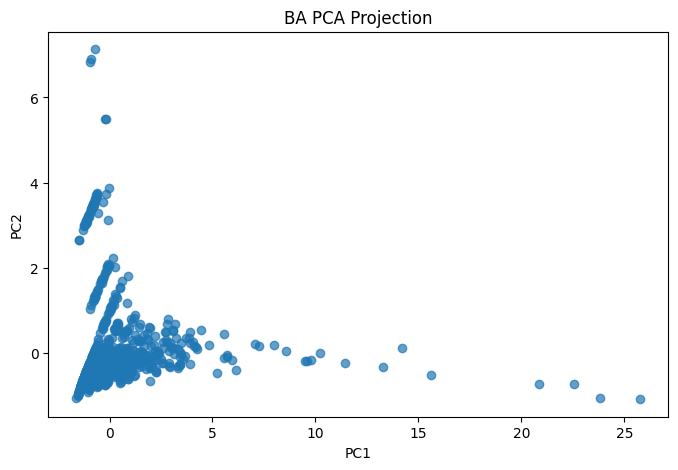

In [16]:
def plot_pca(df: pd.DataFrame, title: str, label_col: str | None = None):
    plt.figure()
    if label_col is None:
        plt.scatter(df["PC1"], df["PC2"], alpha=0.7)
    else:
        for label in sorted(df[label_col].unique()):
            subset = df[df[label_col] == label]
            plt.scatter(subset["PC1"], subset["PC2"], alpha=0.7, label=f"{label_col}={label}")
        plt.legend()
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.show()

plot_pca(df_ba_pca, "BA PCA Projection")

## 5. GMM Clustering

We use **Gaussian Mixture Models (GMMs)** to cluster nodes based on their reduced feature representation. Unlike hard clustering methods, GMMs provide a flexible probabilistic clustering model that can capture elliptical groups in feature space.

We select the number of clusters using the **Bayesian Information Criterion (BIC)**.

In [17]:
def fit_best_gmm(df: pd.DataFrame, cols: list[str], k_range=range(2, 7), random_state: int = 42):
    X = df[cols].values

    best_model = None
    best_k = None
    best_bic = np.inf
    bic_scores = []

    for k in k_range:
        gmm = GaussianMixture(n_components=k, random_state=random_state)
        gmm.fit(X)
        bic = gmm.bic(X)
        bic_scores.append((k, bic))

        if bic < best_bic:
            best_bic = bic
            best_k = k
            best_model = gmm

    out = df.copy()
    out["cluster"] = best_model.predict(X)
    return out, best_model, bic_scores, best_k

In [18]:
df_ba_clustered, gmm_ba, bic_scores_ba, best_k_ba = fit_best_gmm(df_ba_pca, ["PC1", "PC2"])

print("Best k for BA:", best_k_ba)
df_ba_clustered.head()

Best k for BA: 5


,node,degree,pagerank,clustering_coef,betweenness,closeness,model,log_degree,log_pagerank,PC1,PC2,cluster
0,0,52,0.0074,0.0294,0.0718,0.4145,BA,3.9703,0.0073,14.2157,0.1126,2
1,1,31,0.0045,0.0237,0.0310,0.3742,BA,3.4657,0.0045,7.9631,0.1918,2
2,2,4,0.0007,0.3333,0.0016,0.3434,BA,1.6094,0.0007,-0.0252,3.8694,3
3,3,51,0.0073,0.0118,0.0588,0.3901,BA,3.9512,0.0073,13.2962,-0.3284,2
4,4,93,0.0133,0.0129,0.1513,0.4368,BA,4.5433,0.0132,25.7606,-1.0911,2


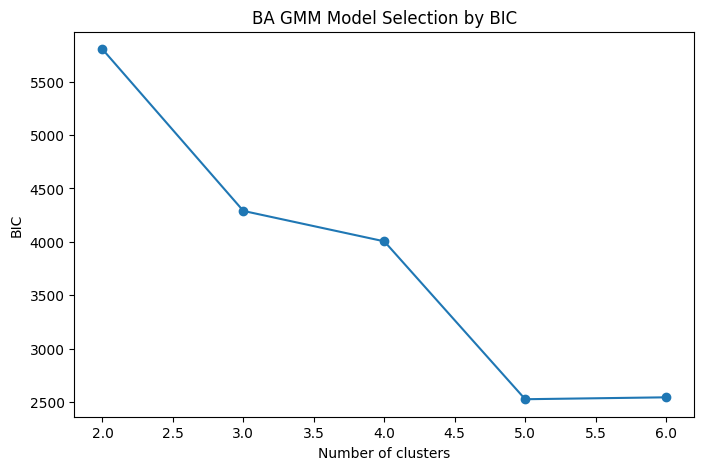

In [19]:
def plot_bic_scores(bic_scores, title: str):
    ks = [k for k, _ in bic_scores]
    bics = [bic for _, bic in bic_scores]

    plt.figure()
    plt.plot(ks, bics, marker="o")
    plt.xlabel("Number of clusters")
    plt.ylabel("BIC")
    plt.title(title)
    plt.show()

plot_bic_scores(bic_scores_ba, "BA GMM Model Selection by BIC")

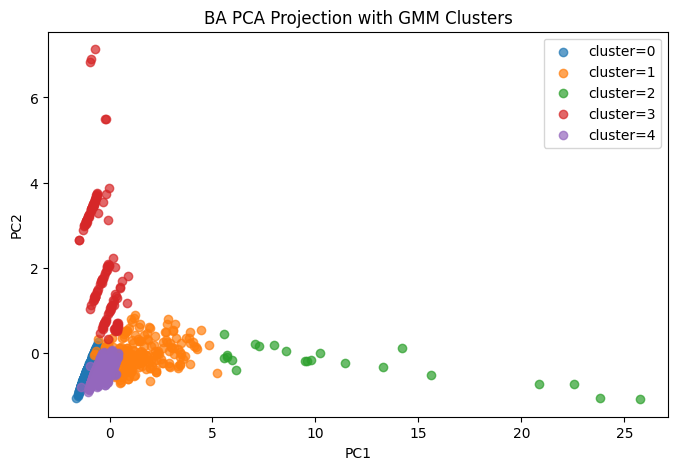

In [20]:
plot_pca(df_ba_clustered, "BA PCA Projection with GMM Clusters", label_col="cluster")

In [21]:
cluster_summary_ba = (
    df_ba_clustered
    .groupby("cluster")[["degree", "pagerank", "clustering_coef", "betweenness", "closeness"]]
    .mean()
    .sort_values("pagerank", ascending=False)
)

cluster_summary_ba

,degree,pagerank,clustering_coef,betweenness,closeness
cluster,,,,,
2,44.0000,0.0064,0.0154,0.0515,0.3798
1,10.0850,0.0016,0.0167,0.0045,0.3146
4,4.6645,0.0008,0.0002,0.0008,0.2808
3,4.1805,0.0007,0.2223,0.0008,0.3055
0,3.0000,0.0006,0.0000,0.0002,0.2751


The cluster summary allows us to interpret the role of each cluster. For example:

- clusters with high degree and high PageRank may represent **hubs**
- clusters with high betweenness but more moderate degree may represent **bridge nodes**
- clusters with low values across most centrality measures may represent **peripheral nodes**

This is more informative than PageRank alone because it captures multiple aspects of structural importance.

## 6. Repeated Experiments Across Models

A single graph realization is not enough to support strong conclusions. To make the analysis more rigorous, we now repeat the full pipeline across multiple random seeds for each graph model.

For each graph realization, we compute:

- summary statistics of PageRank
- degree variability
- the correlation between degree and PageRank
- the number of GMM clusters selected by BIC
- the explained variance from PCA

In [22]:
def analyze_graph(model: str, n: int, seed: int, params: dict) -> tuple[pd.DataFrame, dict]:
    G = generate_graph(model, n=n, seed=seed, **params)
    df = extract_node_features(G, model)

    df_pca, pca, scaler = run_pca(df, feature_cols, n_components=2)
    df_clustered, gmm, bic_scores, best_k = fit_best_gmm(df_pca, ["PC1", "PC2"], random_state=seed)

    result = {
        "model": model,
        "seed": seed,
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "avg_degree": np.mean([d for _, d in G.degree()]),
        "pagerank_std": df["pagerank"].std(),
        "pagerank_max": df["pagerank"].max(),
        "pagerank_gini": gini(df["pagerank"].values),
        "degree_std": df["degree"].std(),
        "degree_pagerank_corr": df[["degree", "pagerank"]].corr().iloc[0, 1],
        "pca_var_pc1": pca.explained_variance_ratio_[0],
        "pca_var_pc2": pca.explained_variance_ratio_[1],
        "num_clusters": best_k
    }

    return df_clustered, result

In [23]:
all_node_results = []
all_graph_results = []

seeds = range(10)

for seed in seeds:
    df_er_run, er_result = analyze_graph("ER", N, seed, ER_PARAMS)
    df_ws_run, ws_result = analyze_graph("WS", N, seed, WS_PARAMS)
    df_ba_run, ba_result = analyze_graph("BA", N, seed, BA_PARAMS)

    all_node_results.extend([df_er_run, df_ws_run, df_ba_run])
    all_graph_results.extend([er_result, ws_result, ba_result])

results_df = pd.DataFrame(all_graph_results)
nodes_df = pd.concat(all_node_results, ignore_index=True)

results_df.head()

,model,seed,nodes,edges,avg_degree,pagerank_std,pagerank_max,pagerank_gini,degree_std,degree_pagerank_corr,pca_var_pc1,pca_var_pc2,num_clusters
0,ER,0,1000,14945,29.890,0.0002,0.0015,0.0880,5.5240,0.9995,0.8449,0.1431,2
1,WS,0,1000,3000,6.000,0.0002,0.0017,0.0838,1.1087,0.9927,0.7389,0.1988,6
2,BA,0,1000,2991,5.982,0.0010,0.0174,0.3287,7.2219,0.9994,0.7286,0.1606,6
3,ER,1,1000,15081,30.162,0.0002,0.0016,0.0870,5.4794,0.9995,0.8454,0.1429,2
4,WS,1,1000,3000,6.000,0.0001,0.0015,0.0787,1.0330,0.9912,0.7334,0.2052,5


In [24]:
results_df.groupby("model").agg(["mean", "std"])

seed           nodes         edges           avg_degree          \
      mean     std    mean  std     mean       std       mean     std   
model                                                                   
BA     4.5  3.0277  1000.0  0.0   2991.0    0.0000      5.982  0.0000   
ER     4.5  3.0277  1000.0  0.0  14977.0  102.8462     29.954  0.2057   
WS     4.5  3.0277  1000.0  0.0   3000.0    0.0000      6.000  0.0000   

      pagerank_std             pagerank_max             pagerank_gini          \
              mean         std         mean         std          mean     std   
model                                                                           
BA          0.0010  5.9406e-05       0.0143  2.8422e-03        0.3260  0.0033   
ER          0.0002  3.9748e-06       0.0015  5.5220e-05        0.0854  0.0022   
WS          0.0001  5.1264e-06       0.0016  8.8609e-05        0.0795  0.0027   

      degree_std         degree_pagerank_corr             pca_var_pc1          \
            mean     std                 mean         std        mean     std   
model                                                                           
BA        7.0358  0.4073               0.9995  9.6458e-05      0.7353  0.0117   
ER        5.3633  0.1252               0.9995  1.3604e-05      0.8451  0.0006   
WS        1.0433  0.0352               0.9919  7.8179e-04      0.7328  0.0057   

      pca_var_pc2         num_clusters          
             mean     std         mean     std  
model                                           
BA         0.1563  0.0046          5.4  0.5164  
ER         0.1429  0.0002          2.0  0.0000  
WS         0.2050  0.0038          5.2  0.6325

The table above summarizes repeated experiments across graph models. Averaging over multiple random seeds reduces the chance that our conclusions are driven by a single atypical graph realization.

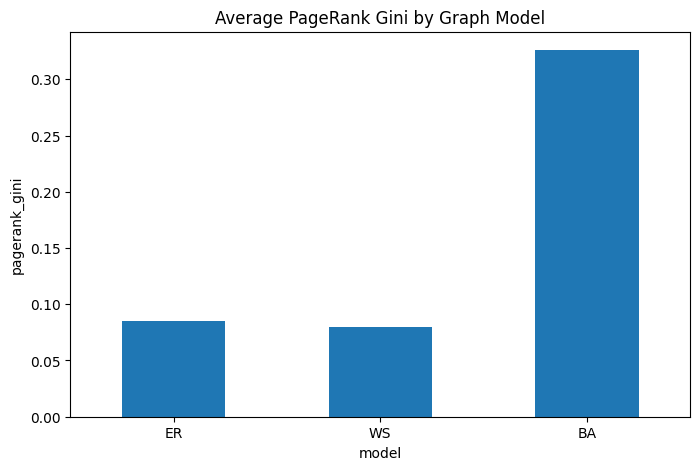

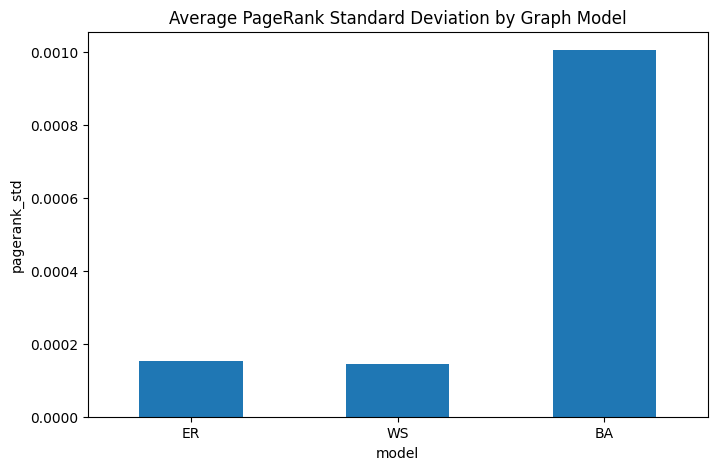

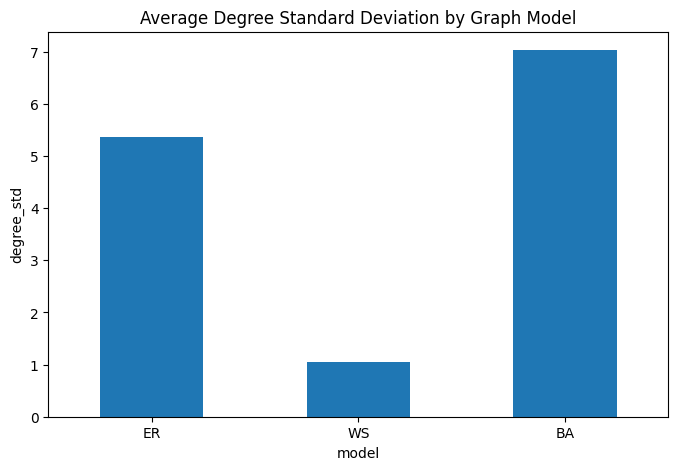

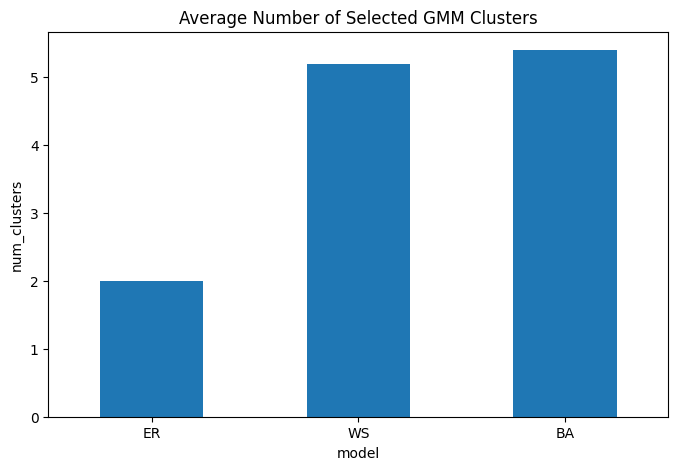

In [25]:
def plot_model_comparison(results_df: pd.DataFrame, metric: str, title: str):
    summary = results_df.groupby("model")[metric].mean().reindex(["ER", "WS", "BA"])
    plt.figure()
    summary.plot(kind="bar")
    plt.ylabel(metric)
    plt.title(title)
    plt.xticks(rotation=0)
    plt.show()

plot_model_comparison(results_df, "pagerank_gini", "Average PageRank Gini by Graph Model")
plot_model_comparison(results_df, "pagerank_std", "Average PageRank Standard Deviation by Graph Model")
plot_model_comparison(results_df, "degree_std", "Average Degree Standard Deviation by Graph Model")
plot_model_comparison(results_df, "num_clusters", "Average Number of Selected GMM Clusters")

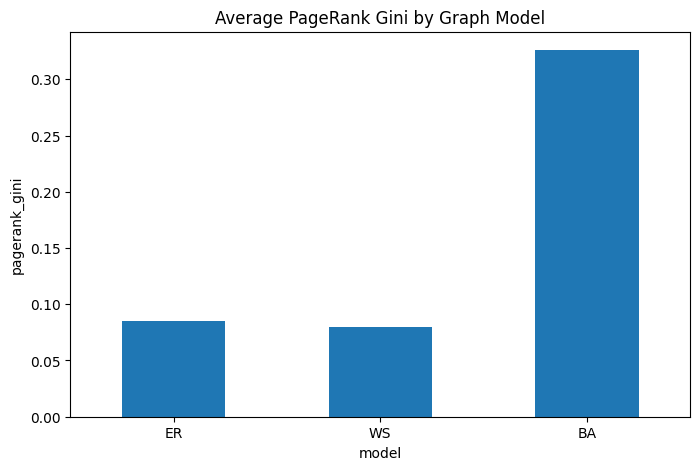

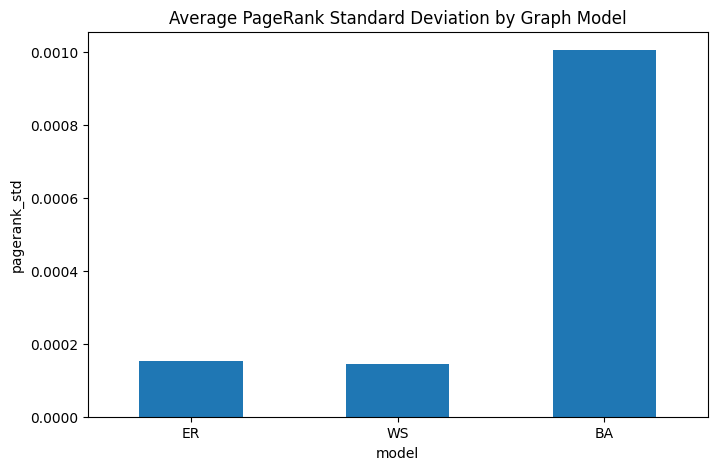

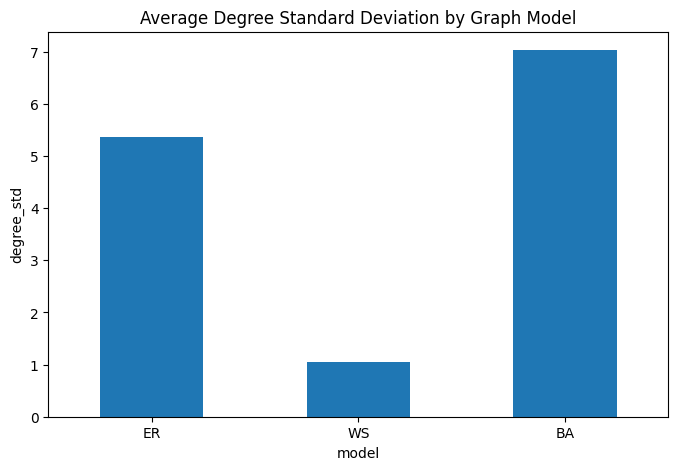

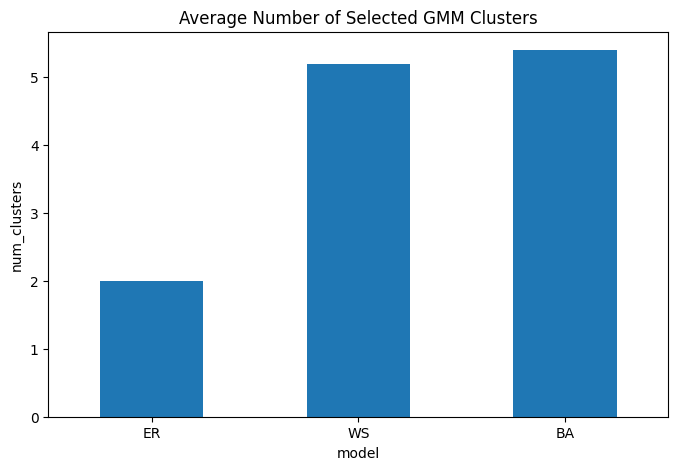

In [26]:
def plot_model_comparison(results_df: pd.DataFrame, metric: str, title: str):
    summary = results_df.groupby("model")[metric].mean().reindex(["ER", "WS", "BA"])
    plt.figure()
    summary.plot(kind="bar")
    plt.ylabel(metric)
    plt.title(title)
    plt.xticks(rotation=0)
    plt.show()

plot_model_comparison(results_df, "pagerank_gini", "Average PageRank Gini by Graph Model")
plot_model_comparison(results_df, "pagerank_std", "Average PageRank Standard Deviation by Graph Model")
plot_model_comparison(results_df, "degree_std", "Average Degree Standard Deviation by Graph Model")
plot_model_comparison(results_df, "num_clusters", "Average Number of Selected GMM Clusters")

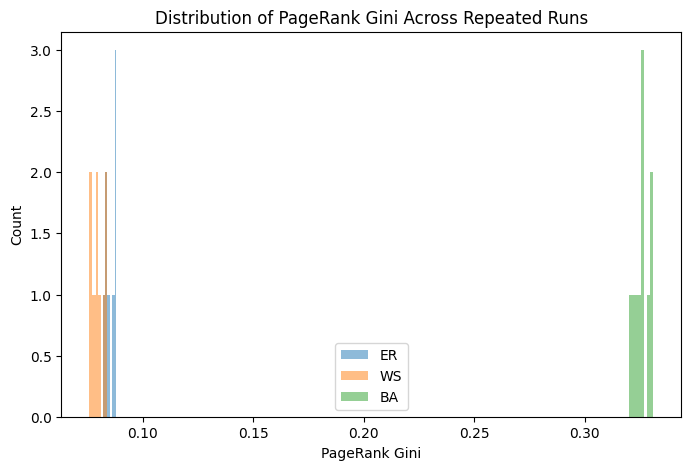

In [27]:
plt.figure()
for model in ["ER", "WS", "BA"]:
    subset = results_df[results_df["model"] == model]
    plt.hist(subset["pagerank_gini"], alpha=0.5, bins=8, label=model)
plt.xlabel("PageRank Gini")
plt.ylabel("Count")
plt.title("Distribution of PageRank Gini Across Repeated Runs")
plt.legend()
plt.show()

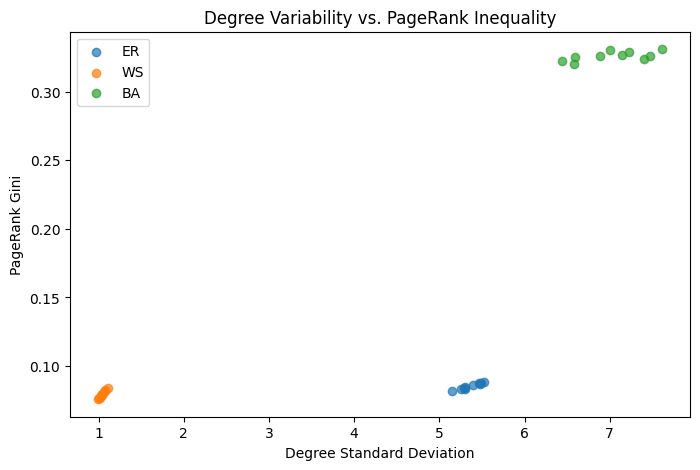

In [28]:
plt.figure()
for model in ["ER", "WS", "BA"]:
    subset = results_df[results_df["model"] == model]
    plt.scatter(subset["degree_std"], subset["pagerank_gini"], alpha=0.7, label=model)
plt.xlabel("Degree Standard Deviation")
plt.ylabel("PageRank Gini")
plt.title("Degree Variability vs. PageRank Inequality")
plt.legend()
plt.show()

## 7. Cross-Model PCA Visualization

We can also compare node-level structure across models by combining the node feature data and projecting them together into a common PCA space.

In [29]:
combined_features = nodes_df[feature_cols].values
combined_scaled = StandardScaler().fit_transform(combined_features)

combined_pca = PCA(n_components=2)
combined_pca_values = combined_pca.fit_transform(combined_scaled)

nodes_df = nodes_df.copy()
nodes_df["global_PC1"] = combined_pca_values[:, 0]
nodes_df["global_PC2"] = combined_pca_values[:, 1]

print("Combined explained variance ratio:", combined_pca.explained_variance_ratio_)

Combined explained variance ratio: [0.51555528 0.34655717]


This combined PCA view helps illustrate whether the different graph models produce systematically different node-level feature distributions. If the clouds of points differ visibly, that suggests that graph generation mechanism strongly shapes the kinds of node roles that appear.

In [30]:
results_summary = (
    results_df.groupby("model")[[
        "pagerank_std",
        "pagerank_max",
        "pagerank_gini",
        "degree_std",
        "degree_pagerank_corr",
        "num_clusters"
    ]]
    .mean()
    .reindex(["ER", "WS", "BA"])
)

results_summary

,pagerank_std,pagerank_max,pagerank_gini,degree_std,degree_pagerank_corr,num_clusters
model,,,,,,
ER,0.0002,0.0015,0.0854,5.3633,0.9995,2.0
WS,0.0001,0.0016,0.0795,1.0433,0.9919,5.2
BA,0.0010,0.0143,0.3260,7.0358,0.9995,5.4


## Discussion

Several patterns emerge from the repeated experiments:

1. **Barabási–Albert graphs** tend to produce the most unequal influence distributions. This is consistent with their preferential attachment mechanism, which naturally creates hubs. As a result, a small number of nodes can dominate the PageRank distribution.

2. **Erdős–Rényi graphs** are typically more homogeneous. Their random edge structure produces weaker hub formation and lower inequality in PageRank.

3. **Watts–Strogatz graphs** often occupy a middle ground. They may not produce hubs as extreme as Barabási–Albert graphs, but their local clustering and short path lengths can still create meaningful structural variation.

4. The GMM clustering results suggest that nodes can often be grouped into structural roles such as hubs, bridge-like nodes, and peripheral nodes. This supports the idea that graph-derived features capture meaningful structural distinctions.

5. Repeating the experiment across multiple seeds strengthens these conclusions by showing that the qualitative patterns are not limited to a single graph realization.

## Application Relevance

These findings matter in applications such as disease spread or antidote distribution. In a graph with highly concentrated influence, targeting a small number of high-PageRank nodes may be especially effective. In more homogeneous graphs, intervention may need to be distributed more broadly.

## 11. Simulated Spread Experiment

To connect our structural analysis to a more application-oriented setting, we simulate a simple diffusion process on each graph.

We use an SI-style model:
- each node begins as susceptible except for one initial infected seed
- at each time step, infected nodes infect susceptible neighbors with probability \( \beta \)
- infected nodes remain infected permanently

We compare spread dynamics when the initial seed node is chosen in three ways:

1. highest PageRank node
2. highest degree node
3. a random node

This helps test whether centrality-based seed selection leads to faster or broader spread, and whether that effect depends on graph structure.

In [34]:
def simulate_si_spread(G, initial_infected, beta=0.2, steps=20, rng=None):
    """
    Simulate an SI process on graph G.

    Parameters
    ----------
    G : networkx.Graph
        Graph on which spread occurs.
    initial_infected : int
        Initial infected node.
    beta : float
        Infection probability per infected-susceptible edge per step.
    steps : int
        Number of simulation steps.
    rng : np.random.Generator or None
        Random number generator.

    Returns
    -------
    infected_counts : list[int]
        Number of infected nodes at each time step, including step 0.
    infected_fraction : list[float]
        Fraction infected at each time step.
    """
    if rng is None:
        rng = np.random.default_rng()

    infected = {initial_infected}
    infected_counts = [1]
    infected_fraction = [1 / G.number_of_nodes()]

    for _ in range(steps):
        new_infected = set(infected)

        for node in infected:
            for neighbor in G.neighbors(node):
                if neighbor not in infected:
                    if rng.random() < beta:
                        new_infected.add(neighbor)

        infected = new_infected
        infected_counts.append(len(infected))
        infected_fraction.append(len(infected) / G.number_of_nodes())

    return infected_counts, infected_fraction

In [35]:
def get_seed_nodes(df):
    top_pagerank_node = df.loc[df["pagerank"].idxmax(), "node"]
    top_degree_node = df.loc[df["degree"].idxmax(), "node"]
    random_node = np.random.choice(df["node"].values)

    return {
        "top_pagerank": top_pagerank_node,
        "top_degree": top_degree_node,
        "random": random_node
    }

In [36]:
def plot_spread_curves(curves_dict, title):
    plt.figure()
    for label, frac_infected in curves_dict.items():
        plt.plot(frac_infected, marker="o", label=label)
    plt.xlabel("Time step")
    plt.ylabel("Fraction infected")
    plt.title(title)
    plt.legend()
    plt.show()

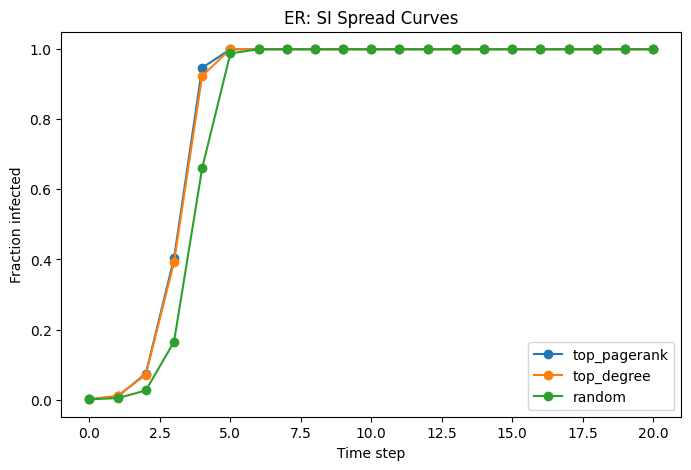

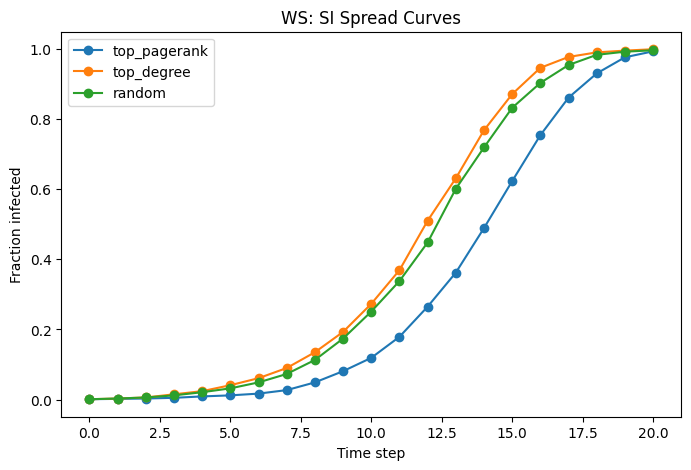

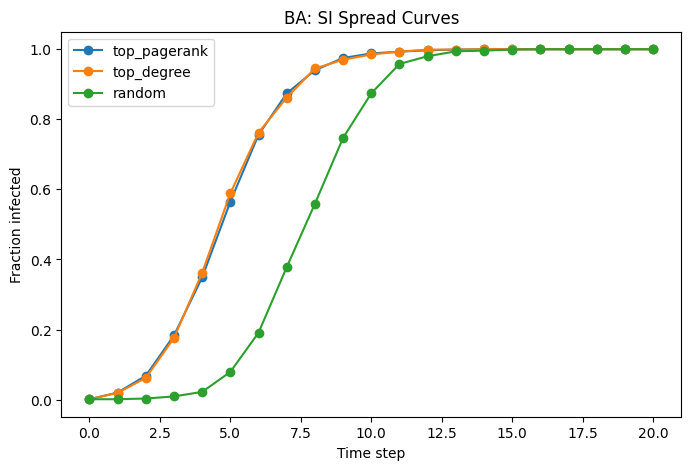

In [37]:
beta = 0.2
steps = 20
rng = np.random.default_rng(42)

example_graphs = {
    "ER": (G_er, df_er),
    "WS": (G_ws, df_ws),
    "BA": (G_ba, df_ba),
}

for model_name, (G, df) in example_graphs.items():
    seeds = get_seed_nodes(df)
    curves = {}

    for seed_type, seed_node in seeds.items():
        counts, fractions = simulate_si_spread(
            G,
            initial_infected=seed_node,
            beta=beta,
            steps=steps,
            rng=rng
        )
        curves[seed_type] = fractions

    plot_spread_curves(curves, f"{model_name}: SI Spread Curves")

In [38]:
def time_to_threshold(fractions, threshold):
    for t, frac in enumerate(fractions):
        if frac >= threshold:
            return t
    return np.nan

In [39]:
def run_spread_experiment(model, n, graph_params, graph_seed, beta=0.2, steps=20, sim_reps=20):
    G = generate_graph(model, n=n, seed=graph_seed, **graph_params)
    df = extract_node_features(G, model)
    seeds = get_seed_nodes(df)

    records = []

    for seed_type, seed_node in seeds.items():
        for sim_rep in range(sim_reps):
            rng = np.random.default_rng(10_000 * graph_seed + sim_rep)

            counts, fractions = simulate_si_spread(
                G,
                initial_infected=seed_node,
                beta=beta,
                steps=steps,
                rng=rng
            )

            records.append({
                "model": model,
                "graph_seed": graph_seed,
                "seed_type": seed_type,
                "sim_rep": sim_rep,
                "final_fraction_infected": fractions[-1],
                "t_25": time_to_threshold(fractions, 0.25),
                "t_50": time_to_threshold(fractions, 0.50),
                "t_75": time_to_threshold(fractions, 0.75),
            })

    return pd.DataFrame(records)

In [40]:
spread_results = []

for seed in range(10):
    spread_results.append(run_spread_experiment("ER", N, ER_PARAMS, graph_seed=seed, beta=0.2, steps=20, sim_reps=10))
    spread_results.append(run_spread_experiment("WS", N, WS_PARAMS, graph_seed=seed, beta=0.2, steps=20, sim_reps=10))
    spread_results.append(run_spread_experiment("BA", N, BA_PARAMS, graph_seed=seed, beta=0.2, steps=20, sim_reps=10))

spread_results_df = pd.concat(spread_results, ignore_index=True)
spread_results_df.head()

,model,graph_seed,seed_type,sim_rep,final_fraction_infected,t_25,t_50,t_75
0,ER,0,top_pagerank,0,1.0,3,4.0,4.0
1,ER,0,top_pagerank,1,1.0,3,4.0,4.0
2,ER,0,top_pagerank,2,1.0,3,4.0,4.0
3,ER,0,top_pagerank,3,1.0,3,4.0,4.0
4,ER,0,top_pagerank,4,1.0,3,4.0,4.0


In [41]:
spread_summary = (
    spread_results_df
    .groupby(["model", "seed_type"])[["final_fraction_infected", "t_25", "t_50", "t_75"]]
    .mean()
    .round(3)
)

spread_summary

final_fraction_infected   t_25    t_50    t_75
model seed_type                                                   
BA    random                          1.000   7.08   8.280   9.550
      top_degree                      1.000   4.00   5.090   6.420
      top_pagerank                    1.000   4.00   5.090   6.420
ER    random                          1.000   3.47   4.050   4.250
      top_degree                      1.000   3.04   3.940   4.010
      top_pagerank                    1.000   3.04   3.940   4.010
WS    random                          0.969  12.21  14.204  16.020
      top_degree                      0.996  10.45  12.500  14.360
      top_pagerank                    0.994  10.51  12.580  14.364

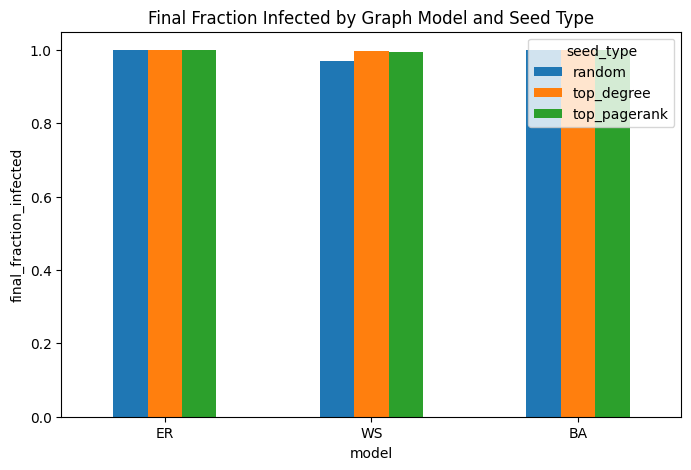

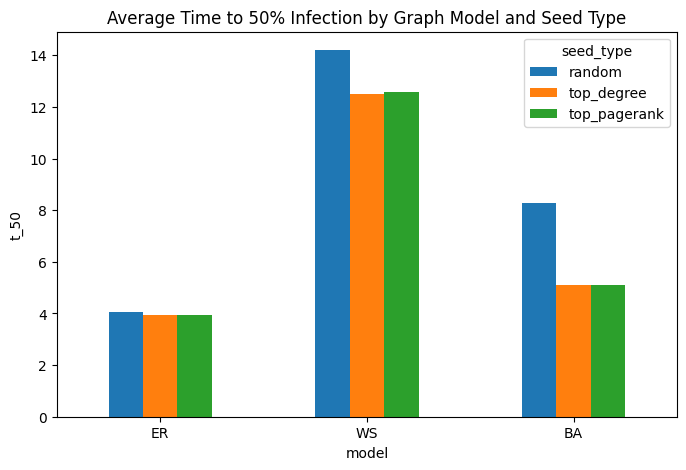

In [42]:
def plot_metric_by_seed_type(df, metric, title):
    summary = (
        df.groupby(["model", "seed_type"])[metric]
        .mean()
        .unstack()
        .reindex(["ER", "WS", "BA"])
    )

    summary.plot(kind="bar")
    plt.ylabel(metric)
    plt.title(title)
    plt.xticks(rotation=0)
    plt.show()

plot_metric_by_seed_type(
    spread_results_df,
    "final_fraction_infected",
    "Final Fraction Infected by Graph Model and Seed Type"
)

plot_metric_by_seed_type(
    spread_results_df,
    "t_50",
    "Average Time to 50% Infection by Graph Model and Seed Type"
)

## 12. Antidote Dispersion as an Intervention Experiment

To connect the graph analysis to the motivating application of disease spread and antidote allocation, we study a simple intervention problem.

We interpret antidote distribution as a prophylactic intervention applied before diffusion begins. In particular, we compare three strategies:

1. **No intervention**
2. **Targeted intervention**: protect the top 5 PageRank nodes
3. **Random intervention**: protect 5 randomly selected nodes

Operationally, protected nodes are removed from the graph before the spread simulation begins. This corresponds to a setting in which these nodes are effectively immunized and cannot participate in transmission.

We then simulate diffusion on the remaining network and compare outcomes across graph models and intervention strategies.

In [43]:
def remove_nodes_by_strategy(G, df, strategy, k=5, rng=None):
    """
    Return a modified graph after removing nodes according to strategy.

    Parameters
    ----------
    G : networkx.Graph
    df : pd.DataFrame
        Node feature dataframe containing 'node' and 'pagerank'
    strategy : str
        One of: 'none', 'targeted_pagerank', 'random'
    k : int
        Number of nodes to remove for intervention
    rng : np.random.Generator or None
    """
    if rng is None:
        rng = np.random.default_rng()

    G_mod = G.copy()

    if strategy == "none":
        removed_nodes = []
    elif strategy == "targeted_pagerank":
        removed_nodes = (
            df.sort_values("pagerank", ascending=False)
              .head(k)["node"]
              .tolist()
        )
        G_mod.remove_nodes_from(removed_nodes)
    elif strategy == "random":
        candidate_nodes = list(G.nodes())
        removed_nodes = rng.choice(candidate_nodes, size=k, replace=False).tolist()
        G_mod.remove_nodes_from(removed_nodes)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    return G_mod, removed_nodes

In [44]:
def simulate_si_spread(G, initial_infected, beta=0.2, steps=20, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    infected = {initial_infected}
    infected_counts = [1]
    infected_fraction = [1 / G.number_of_nodes()]

    for _ in range(steps):
        new_infected = set(infected)

        for node in infected:
            for neighbor in G.neighbors(node):
                if neighbor not in infected:
                    if rng.random() < beta:
                        new_infected.add(neighbor)

        infected = new_infected
        infected_counts.append(len(infected))
        infected_fraction.append(len(infected) / G.number_of_nodes())

    return infected_counts, infected_fraction

In [46]:
def mean_ci(series, z=1.96):
    """
    Compute mean and approximate 95% confidence interval.
    """
    x = pd.Series(series).dropna()
    n = len(x)

    if n == 0:
        return pd.Series({
            "mean": np.nan,
            "std": np.nan,
            "n": 0,
            "ci_lower": np.nan,
            "ci_upper": np.nan
        })

    mean = x.mean()
    std = x.std(ddof=1) if n > 1 else 0.0
    se = std / np.sqrt(n) if n > 1 else 0.0

    return pd.Series({
        "mean": mean,
        "std": std,
        "n": n,
        "ci_lower": mean - z * se,
        "ci_upper": mean + z * se
    })

In [49]:
def run_intervention_spread_experiment(
    model,
    n,
    graph_params,
    graph_seed,
    intervention_strategy,
    beta=0.2,
    steps=20,
    k_remove=5,
    sim_reps=30
):
    """
    For one graph realization, apply an intervention strategy and simulate spread
    multiple times from random remaining seeds.
    """
    rng_graph = np.random.default_rng(graph_seed)

    G = generate_graph(model, n=n, seed=graph_seed, **graph_params)
    df = extract_node_features(G, model)

    G_mod, removed_nodes = remove_nodes_by_strategy(
        G, df, strategy=intervention_strategy, k=k_remove, rng=rng_graph
    )

    records = []

    if G_mod.number_of_nodes() == 0:
        return pd.DataFrame()

    remaining_nodes = list(G_mod.nodes())

    for sim_rep in range(sim_reps):
        rng = np.random.default_rng(100000 * graph_seed + sim_rep)

        initial_infected = rng.choice(remaining_nodes)

        counts, fractions = simulate_si_spread(
            G_mod,
            initial_infected=initial_infected,
            beta=beta,
            steps=steps,
            rng=rng
        )

        auc = np.trapezoid(np.array(fractions), dx=1)

        records.append({
            "model": model,
            "graph_seed": graph_seed,
            "strategy": intervention_strategy,
            "sim_rep": sim_rep,
            "nodes_remaining": G_mod.number_of_nodes(),
            "edges_remaining": G_mod.number_of_edges(),
            "final_fraction_infected": fractions[-1],
            "t_25": time_to_threshold(fractions, 0.25),
            "t_50": time_to_threshold(fractions, 0.50),
            "t_75": time_to_threshold(fractions, 0.75),
            "auc_infected": auc,
            "removed_nodes": removed_nodes
        })

    return pd.DataFrame(records)

In [52]:
intervention_results = []

strategies = ["none", "targeted_pagerank", "random"]

for seed in range(10):
    for strategy in strategies:
        intervention_results.append(
            run_intervention_spread_experiment(
                model="ER",
                n=N,
                graph_params=ER_PARAMS,
                graph_seed=seed,
                intervention_strategy=strategy,
                beta=0.2,
                steps=20,
                k_remove=100,
                sim_reps=20
            )
        )

        intervention_results.append(
            run_intervention_spread_experiment(
                model="WS",
                n=N,
                graph_params=WS_PARAMS,
                graph_seed=seed,
                intervention_strategy=strategy,
                beta=0.2,
                steps=20,
                k_remove=100,
                sim_reps=20
            )
        )

        intervention_results.append(
            run_intervention_spread_experiment(
                model="BA",
                n=N,
                graph_params=BA_PARAMS,
                graph_seed=seed,
                intervention_strategy=strategy,
                beta=0.2,
                steps=20,
                k_remove=100,
                sim_reps=20
            )
        )

intervention_df = pd.concat(intervention_results, ignore_index=True)
intervention_df.head()

,model,graph_seed,strategy,sim_rep,nodes_remaining,edges_remaining,final_fraction_infected,t_25,t_50,t_75,auc_infected,removed_nodes
0,ER,0,none,0,1000,14945,1.0,3.0,4.0,4.0,16.7945,[]
1,ER,0,none,1,1000,14945,1.0,4.0,4.0,5.0,16.2725,[]
2,ER,0,none,2,1000,14945,1.0,3.0,4.0,4.0,16.7995,[]
3,ER,0,none,3,1000,14945,1.0,3.0,4.0,4.0,16.6285,[]
4,ER,0,none,4,1000,14945,1.0,4.0,4.0,5.0,16.4125,[]


In [53]:
final_fraction_summary = (
    intervention_df
    .groupby(["model", "strategy"])["final_fraction_infected"]
    .apply(mean_ci)
    .unstack()
)

final_fraction_summary

mean     std      n  ci_lower  ci_upper
model strategy                                                    
BA    none               0.9996  0.0018  200.0    0.9993    0.9998
      random             0.9964  0.0046  200.0    0.9958    0.9970
      targeted_pagerank  0.2490  0.1764  200.0    0.2246    0.2735
ER    none               1.0000  0.0000  200.0    1.0000    1.0000
      random             1.0000  0.0000  200.0    1.0000    1.0000
      targeted_pagerank  1.0000  0.0000  200.0    1.0000    1.0000
WS    none               0.9858  0.0280  200.0    0.9819    0.9897
      random             0.9283  0.1037  200.0    0.9139    0.9426
      targeted_pagerank  0.7346  0.1664  200.0    0.7115    0.7576

In [54]:
t50_summary = (
    intervention_df
    .groupby(["model", "strategy"])["t_50"]
    .apply(mean_ci)
    .unstack()
)

t50_summary

mean     std      n  ci_lower  ci_upper
model strategy                                                     
BA    none                8.5700  1.6761  200.0    8.3377    8.8023
      random              9.2250  1.9631  200.0    8.9529    9.4971
      targeted_pagerank  19.5882  0.5073   17.0   19.3471   19.8294
ER    none                4.0250  0.1565  200.0    4.0033    4.0467
      random              4.0700  0.2558  200.0    4.0345    4.1055
      targeted_pagerank   4.1350  0.3841  200.0    4.0818    4.1882
WS    none               13.9150  1.3701  200.0   13.7251   14.1049
      random             15.1827  1.5243  197.0   14.9699   15.3956
      targeted_pagerank  17.3842  1.5223  177.0   17.1599   17.6085

In [55]:
auc_summary = (
    intervention_df
    .groupby(["model", "strategy"])["auc_infected"]
    .apply(mean_ci)
    .unstack()
)

auc_summary

mean     std      n  ci_lower  ci_upper
model strategy                                                     
BA    none               11.7819  1.6466  200.0   11.5537   12.0101
      random             11.0677  1.9233  200.0   10.8012   11.3343
      targeted_pagerank   1.1700  0.9055  200.0    1.0446    1.2955
ER    none               16.6167  0.2189  200.0   16.5863   16.6470
      random             16.4924  0.2360  200.0   16.4596   16.5251
      targeted_pagerank  16.3533  0.3018  200.0   16.3115   16.3952
WS    none                6.8899  1.2752  200.0    6.7132    7.0666
      random              5.6314  1.4255  200.0    5.4339    5.8290
      targeted_pagerank   3.6986  1.3464  200.0    3.5120    3.8852

In [59]:
summary_rows = []

for metric in ["final_fraction_infected", "t_25", "t_50", "t_75", "auc_infected"]:
    for (model, strategy), group in intervention_df.groupby(["model", "strategy"]):
        stats = mean_ci(group[metric])

        summary_rows.append({
            "model": model,
            "strategy": strategy,
            "metric": metric,
            "mean": stats["mean"],
            "std": stats["std"],
            "n": stats["n"],
            "ci_lower": stats["ci_lower"],
            "ci_upper": stats["ci_upper"],
        })

intervention_summary_df = pd.DataFrame(summary_rows)
intervention_summary_df.head()

,model,strategy,metric,mean,std,n,ci_lower,ci_upper
0,BA,none,final_fraction_infected,0.9996,0.0018,200.0,0.9993,0.9998
1,BA,random,final_fraction_infected,0.9964,0.0046,200.0,0.9958,0.9970
2,BA,targeted_pagerank,final_fraction_infected,0.2490,0.1764,200.0,0.2246,0.2735
3,ER,none,final_fraction_infected,1.0000,0.0000,200.0,1.0000,1.0000
4,ER,random,final_fraction_infected,1.0000,0.0000,200.0,1.0000,1.0000


In [62]:
def plot_metric_with_ci(summary_df, metric, title, ylabel):
    subset = summary_df[summary_df["metric"] == metric].copy()

    model_order = ["ER", "WS", "BA"]
    strategy_order = ["none", "targeted_pagerank", "random"]

    x_positions = []
    means = []
    lower_err = []
    upper_err = []
    labels = []

    pos = 0
    for model in model_order:
        for strategy in strategy_order:
            row = subset[
                (subset["model"] == model) &
                (subset["strategy"] == strategy)
            ]

            if row.empty:
                continue

            row = row.iloc[0]

            x_positions.append(pos)
            means.append(row["mean"])
            lower_err.append(row["mean"] - row["ci_lower"])
            upper_err.append(row["ci_upper"] - row["mean"])
            labels.append(f"{model}\n{strategy}")
            pos += 1

        pos += 1  # gap between models

    yerr = np.array([lower_err, upper_err])

    plt.figure(figsize=(10, 5))
    plt.bar(x_positions, means)
    plt.errorbar(x_positions, means, yerr=yerr, fmt="none", capsize=5)
    plt.xticks(x_positions, labels)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

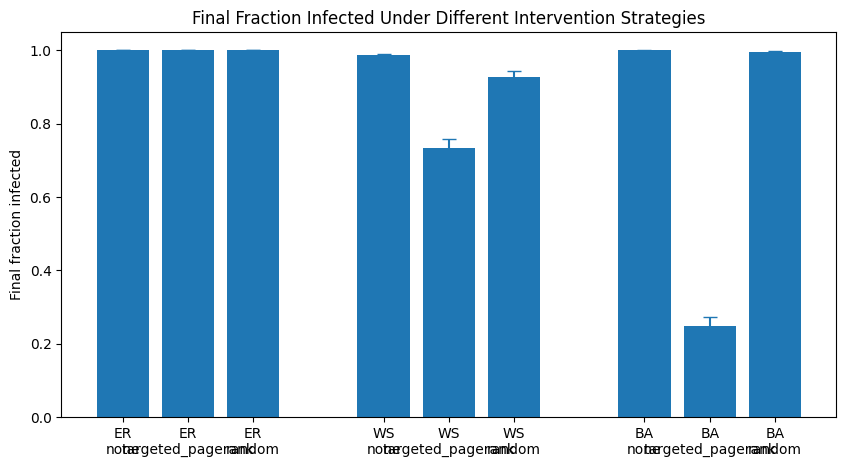

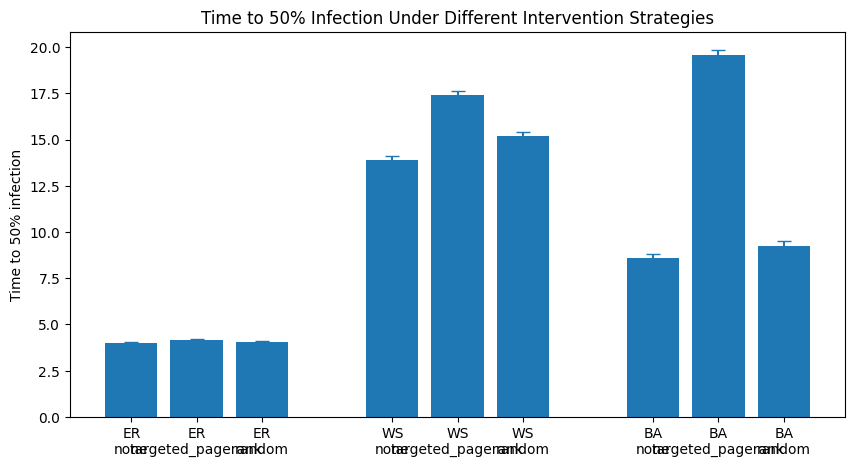

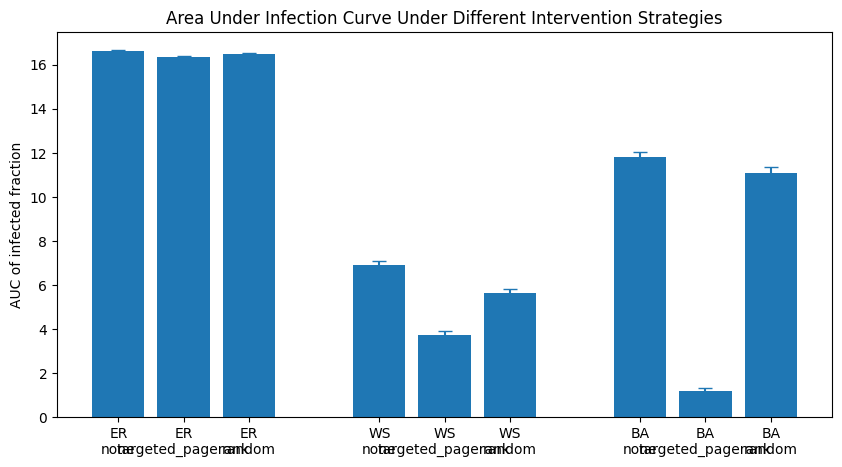

In [63]:
plot_metric_with_ci(
    intervention_summary_df,
    metric="final_fraction_infected",
    title="Final Fraction Infected Under Different Intervention Strategies",
    ylabel="Final fraction infected"
)

plot_metric_with_ci(
    intervention_summary_df,
    metric="t_50",
    title="Time to 50% Infection Under Different Intervention Strategies",
    ylabel="Time to 50% infection"
)

plot_metric_with_ci(
    intervention_summary_df,
    metric="auc_infected",
    title="Area Under Infection Curve Under Different Intervention Strategies",
    ylabel="AUC of infected fraction"
)

In [64]:
pivot_final = (
    intervention_df
    .groupby(["model", "strategy"])["final_fraction_infected"]
    .mean()
    .unstack()
    .reindex(["ER", "WS", "BA"])
)

pivot_final["targeted_minus_random"] = pivot_final["targeted_pagerank"] - pivot_final["random"]
pivot_final["targeted_minus_none"] = pivot_final["targeted_pagerank"] - pivot_final["none"]

pivot_final

strategy,none,random,targeted_pagerank,targeted_minus_random,targeted_minus_none
model,,,,,
ER,1.0000,1.0000,1.0000,0.0000,0.0000
WS,0.9858,0.9283,0.7346,-0.1937,-0.2512
BA,0.9996,0.9964,0.2490,-0.7474,-0.7505


## 13. Intervention Results and Confidence Intervals

The intervention experiment evaluates whether targeted antidote allocation outperforms random allocation.

We compare three strategies:
- no intervention
- removing the top 5 PageRank nodes
- removing 5 random nodes

For each graph model, we repeat the experiment across multiple graph realizations and multiple spread simulations. We summarize outcomes using means and approximate 95% confidence intervals.

This moves the analysis beyond descriptive graph statistics and toward a decision-oriented question: **how should limited intervention resources be allocated to reduce spread most effectively?**